# 08. Linear Models as Inferential Engines

Linear models matter in decision science because they do more than summarize association. They let us estimate adjusted comparisons, quantify uncertainty, test structured hypotheses, and translate a noisy observational dataset into an explicit recommendation. The key is to use them as inferential tools with care about their limits as truth claims.

We develop that posture in a concrete operational setting. We will study a specialist-routing policy in technical support, where hard cases are more likely to receive the policy. That means the raw treated-versus-untreated comparison is misleading. Regression becomes useful precisely because it can separate case mix from the policy signal, express effects in original business units, and attach uncertainty to the answer.


## Learning Objectives

After working through this lecture, you should be able to:

1. explain why a linear model can serve as an adjusted comparison engine, not only as a prediction device;
2. compare raw and regression-adjusted policy estimates in the same operational dataset;
3. interpret regression coefficients as conditional mean differences in original business units;
4. use interaction terms to estimate subgroup-specific effects;
5. distinguish point estimates from standard errors, confidence intervals, and case-level prediction intervals;
6. diagnose why heteroskedasticity matters for inference even when point estimates stay fixed;
7. compare conventional and heteroskedasticity-robust uncertainty estimates; and
8. write a policy recommendation that uses adjusted evidence instead of naive averages.


## Mathematical Core: Linear Models as Contrast Machines

A linear model can be written in matrix form as

$$
Y = X\beta + \varepsilon, \qquad \mathbb{E}[\varepsilon \mid X]=0.
$$

The least-squares estimate is

$$
\hat{\beta} = (X^T X)^{-1}X^T Y
$$

when $X^T X$ is invertible. Many inferential questions are linear contrasts of the coefficient vector:

$$
\hat{\tau} = c^T\hat{\beta}.
$$

For example, an adjusted treatment contrast, an interaction contrast, or a difference between two scenario predictions can all be written this way. Its estimated standard error is

$$
SE(\hat{\tau})=\sqrt{c^T \widehat{\operatorname{Var}}(\hat{\beta})c}.
$$

With an interaction between treatment $T$ and a moderator $Z$, the fitted treatment contrast changes with $Z$:

$$
\mathbb{E}[Y\mid T=1,Z]-\mathbb{E}[Y\mid T=0,Z] = \beta_T + \beta_{T:Z}Z.
$$

If residual variance changes across observations, classical standard errors can be misleading. A heteroskedasticity-robust covariance estimate replaces the constant-variance formula with a sandwich estimate, preserving the same point estimates but changing the uncertainty attached to contrasts.

In [1]:
# Load modeling, plotting, and display tools used throughout the regression examples.
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import Markdown, display
from scipy import stats
from scipy.special import expit
from statsmodels.stats.diagnostic import het_breuschpagan

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'notebooks' / '_shared' / 'display.py').exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

from notebooks._shared.display import smart_display

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f"{x:0.3f}")
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 200)
np.random.seed(2026)

SEVERITY_ORDER = ['Low', 'Medium', 'High', 'Critical']
REGION_ORDER = ['North America', 'Europe', 'Asia Pacific', 'Latin America']
CHANNEL_ORDER = ['Email', 'Chat', 'Phone', 'Escalation']


def make_support_policy_data(seed=2026, n_rows=3200):
    """
    Simulate a confounded technical-support routing dataset.
    
    Parameters:
        seed: Random seed used to make the simulation reproducible.
        n_rows: Number of support tickets to generate.
    
    Returns:
        A pandas DataFrame with routing assignment, case-mix variables, observed resolution time, and hidden true policy effects.
    
    Idea:
        Create a setting where specialist routing is assigned to harder cases, so raw comparisons fail and regression adjustment has a clear inferential role.
    """
    rng = np.random.default_rng(seed)

    severity = rng.choice(SEVERITY_ORDER, size=n_rows, p=[0.34, 0.33, 0.22, 0.11])
    severity_score = pd.Series(severity).map({'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}).to_numpy()

    region = rng.choice(REGION_ORDER, size=n_rows, p=[0.38, 0.23, 0.27, 0.12])
    channel = rng.choice(CHANNEL_ORDER, size=n_rows, p=[0.35, 0.27, 0.28, 0.10])

    backlog_index = rng.normal(0, 1, n_rows) + 0.25 * (severity_score - 2)
    product_complexity = np.clip(rng.beta(2.5, 2.2, size=n_rows) + 0.08 * (severity_score - 2), 0, 1.4)
    prior_incidents = rng.poisson(np.clip(1.6 + 0.8 * (severity_score - 1) + 1.1 * product_complexity, 0.4, None))
    agent_experience_years = np.clip(rng.normal(4.5, 1.8, size=n_rows) - 0.18 * (severity_score - 2), 0.5, None)

    enterprise_account = rng.binomial(
        1,
        expit(-1.0 + 0.35 * (severity_score - 1) + 0.9 * product_complexity),
    )

    routing_probability = expit(
        -1.35
        + 0.9 * (severity_score - 1)
        + 0.85 * enterprise_account
        + 0.8 * product_complexity
        + 0.75 * backlog_index
        - 0.17 * agent_experience_years
        + pd.Series(channel).map({'Email': -0.2, 'Chat': -0.1, 'Phone': 0.2, 'Escalation': 0.65}).to_numpy()
    )
    specialist_routing = rng.binomial(1, routing_probability)

    baseline_hours = (
        5.2
        + 0.9 * severity_score
        + 0.95 * product_complexity
        + 0.85 * backlog_index
        + 0.3 * np.maximum(backlog_index, 0) ** 2
        + 0.28 * prior_incidents
        - 0.24 * agent_experience_years
        + 0.55 * enterprise_account
        + pd.Series(channel).map({'Email': 0.0, 'Chat': -0.25, 'Phone': 0.45, 'Escalation': 1.0}).to_numpy()
        + pd.Series(region).map({'North America': 0.0, 'Europe': 0.15, 'Asia Pacific': 0.35, 'Latin America': 0.55}).to_numpy()
    )

    true_effect_hours = -(
        0.55
        + 0.35 * (severity_score >= 3)
        + 0.28 * enterprise_account
        + 0.18 * np.maximum(backlog_index, 0)
        + 0.12 * product_complexity
    )

    noise_sd = 0.55 + 0.16 * severity_score + 0.24 * np.maximum(backlog_index, 0)
    resolution_hours = baseline_hours + specialist_routing * true_effect_hours + rng.normal(0, noise_sd, n_rows)

    df = pd.DataFrame(
        {
            'resolution_hours': resolution_hours,
            'specialist_routing': specialist_routing,
            'routing_probability': routing_probability,
            'true_effect_hours': true_effect_hours,
            'severity': severity,
            'backlog_index': backlog_index,
            'product_complexity': product_complexity,
            'prior_incidents': prior_incidents,
            'agent_experience_years': agent_experience_years,
            'enterprise_account': enterprise_account,
            'channel': channel,
            'region': region,
        }
    )

    df['severity'] = pd.Categorical(df['severity'], categories=SEVERITY_ORDER, ordered=True)
    df['channel'] = pd.Categorical(df['channel'], categories=CHANNEL_ORDER, ordered=True)
    df['region'] = pd.Categorical(df['region'], categories=REGION_ORDER, ordered=True)
    df['account_type'] = np.where(df['enterprise_account'].eq(1), 'Enterprise', 'Standard')
    return df


def policy_summary_table(df):
    """
    Summarize the naive routing comparison before regression adjustment.
    
    Parameters:
        df: Support-ticket dataset containing the routing indicator, outcome, and hidden true effects.
    
    Returns:
        A one-row pandas DataFrame with treated share, raw treated-control contrast, Welch test output, and hidden true average effect.
    
    Idea:
        Put the misleading raw comparison next to the simulation truth so the need for adjustment is visible before fitting richer models.
    """
    treated = df['specialist_routing'].eq(1)
    control = ~treated
    diff = df.loc[treated, 'resolution_hours'].mean() - df.loc[control, 'resolution_hours'].mean()
    t_stat, p_value = stats.ttest_ind(
        df.loc[treated, 'resolution_hours'],
        df.loc[control, 'resolution_hours'],
        equal_var=False,
    )
    return pd.DataFrame(
        [
            {
                'treated_share': treated.mean(),
                'raw_difference_hours': diff,
                'welch_t_statistic': t_stat,
                'welch_p_value': p_value,
                'true_average_effect_hours': df['true_effect_hours'].mean(),
            }
        ]
    )


def extract_interval(model, term, label, truth=None):
    """
    Extract a coefficient estimate and confidence interval from a fitted regression model.
    
    Parameters:
        model: Fitted statsmodels regression result.
        term: Coefficient name to extract from the model.
        label: Human-readable model label for tables and plots.
        truth: Optional hidden benchmark used in the synthetic simulation.
    
    Returns:
        A dictionary with the estimate, standard error, confidence limits, model label, and optional truth reference.
    
    Idea:
        Standardize coefficient summaries so raw, adjusted, and flexible-model estimates can be compared on one plot.
    """
    ci = model.conf_int().loc[term]
    return {
        'model': label,
        'estimate_hours': model.params[term],
        'std_error': model.bse[term],
        'ci_lower': ci.iloc[0],
        'ci_upper': ci.iloc[1],
        'true_average_effect_hours': truth,
    }


def subgroup_effect_table(model, df):
    """
    Estimate severity-specific routing effects from the interaction model.
    
    Parameters:
        model: Fitted statsmodels model containing routing-by-severity interaction terms.
        df: Support-ticket dataset used to compute hidden severity-specific truth references.
    
    Returns:
        A pandas DataFrame with estimated effects, standard errors, confidence intervals, and hidden truth by severity group.
    
    Idea:
        Translate interaction coefficients into subgroup contrasts that can guide deployment decisions.
    """
    hypotheses = {
        'Low': 'specialist_routing = 0',
        'Medium': 'specialist_routing + specialist_routing:C(severity)[T.Medium] = 0',
        'High': 'specialist_routing + specialist_routing:C(severity)[T.High] = 0',
        'Critical': 'specialist_routing + specialist_routing:C(severity)[T.Critical] = 0',
    }

    rows = []
    truth = df.groupby('severity', observed=False)['true_effect_hours'].mean()
    for severity, hypothesis in hypotheses.items():
        test = model.t_test(hypothesis)
        ci = np.asarray(test.conf_int()).reshape(-1, 2)[0]
        rows.append(
            {
                'severity': severity,
                'estimated_effect_hours': float(np.asarray(test.effect).ravel()[0]),
                'std_error': float(np.asarray(test.sd).ravel()[0]),
                'ci_lower': float(ci[0]),
                'ci_upper': float(ci[1]),
                'true_average_effect_hours': truth.loc[severity],
            }
        )
    return pd.DataFrame(rows)


def robust_comparison_table(model, terms):
    """
    Compare classical and HC3 robust standard errors for selected model terms.
    
    Parameters:
        model: Fitted statsmodels regression result whose covariance estimates will be compared.
        terms: Coefficient names to include in the comparison table.
    
    Returns:
        A pandas DataFrame with classical standard errors, HC3 standard errors, and corresponding p-values for each term.
    
    Idea:
        Show that heteroskedasticity affects uncertainty calculations even when the fitted coefficients themselves do not change.
    """
    robust = model.get_robustcov_results(cov_type='HC3')
    name_to_idx = {name: idx for idx, name in enumerate(model.params.index)}
    rows = []
    for term in terms:
        idx = name_to_idx[term]
        rows.append(
            {
                'term': term,
                'classical_se': model.bse[term],
                'hc3_se': robust.bse[idx],
                'classical_p_value': model.pvalues[term],
                'hc3_p_value': robust.pvalues[idx],
            }
        )
    return pd.DataFrame(rows)


def paired_scenario_predictions(model, scenarios):
    """
    Generate mean and individual-case prediction intervals for paired decision scenarios.
    
    Parameters:
        model: Fitted statsmodels regression result used for scenario prediction.
        scenarios: DataFrame describing the ticket scenarios and routing states to compare.
    
    Returns:
        A pandas DataFrame with scenario descriptors, predicted means, mean confidence intervals, and individual prediction intervals.
    
    Idea:
        Move from coefficient tables to scenario-level quantities that decision makers can reason about directly.
    """
    prediction = model.get_prediction(scenarios).summary_frame(alpha=0.05)
    out = pd.concat([scenarios.reset_index(drop=True), prediction.reset_index(drop=True)], axis=1)
    cols = [
        'scenario',
        'specialist_routing',
        'severity',
        'backlog_index',
        'enterprise_account',
        'mean',
        'mean_ci_lower',
        'mean_ci_upper',
        'obs_ci_lower',
        'obs_ci_upper',
    ]
    out = out[cols].copy()
    out['routing_label'] = np.where(out['specialist_routing'].eq(1), 'With specialist routing', 'Without specialist routing')
    out['account_type'] = np.where(out['enterprise_account'].eq(1), 'Enterprise', 'Standard')
    return out

## 1. Regression as an Adjusted Comparison Device

Here the linear model is an adjusted comparison device. It gives us a disciplined way to compare cases that differ on many relevant dimensions.

The inferential target is a conditional mean model of the form

$$
E[Y_i \mid X_i] \approx \beta_0 + \beta_1 X_{i1} + \cdots + \beta_p X_{ip}.
$$

When the specification is informative, the model does three useful things at once:

1. it defines the comparison we care about,
2. it expresses that comparison in outcome units, and
3. it attaches uncertainty to the estimate.

That last point is why the phrase *inferential engine* fits. A regression can convert a messy observational question into coefficient estimates, confidence intervals, contrasts, and scenario-level forecasts. Even when the linear specification is not literally true, it can still be useful as a best linear approximation to the conditional mean if we interpret it carefully with practical caution (White, 1982).


## 2. Setup: A Technical-Support Routing Policy

Suppose an operations team can route certain incoming cases to a specialist queue. Specialist handling is costly, so leadership wants to know whether it meaningfully reduces resolution time and for which kinds of tickets.

The problem is that routing is **not random**. Harder cases are more likely to receive specialist handling. Enterprise customers are more likely to receive it. Backlogged periods are more likely to trigger it. So a raw treated-versus-untreated comparison will conflate policy impact with case severity and queue pressure.

We simulate that environment explicitly so we can inspect both the observed data and the hidden truth.


,resolution_hours,specialist_routing,routing_probability,true_effect_hours,severity,backlog_index,product_complexity,prior_incidents,agent_experience_years,enterprise_account,channel,region,account_type
0,8.231,0,0.287,-0.786,Low,0.858,0.675,3,3.187,0,Email,North America,Standard
1,6.497,0,0.224,-0.595,Medium,-0.536,0.373,2,2.885,0,Email,Asia Pacific,Standard
2,6.115,0,0.278,-0.659,Medium,0.130,0.717,1,5.743,0,Email,Asia Pacific,Standard
3,8.816,1,0.792,-1.077,Medium,1.269,0.159,1,2.024,1,Phone,Asia Pacific,Enterprise
4,8.757,0,0.398,-0.895,Medium,-0.259,0.544,6,5.605,1,Chat,North America,Enterprise


,treated_share,raw_difference_hours,welch_t_statistic,welch_p_value,true_average_effect_hours
0,0.460,1.155,15.917,0.000,-0.943


,severity,account_type,policy_rate,avg_resolution_hours,avg_backlog,cases
0,Low,Enterprise,0.314,6.490,-0.216,401
1,Low,Standard,0.146,6.143,-0.271,676
2,Medium,Enterprise,0.504,7.804,-0.011,470
3,Medium,Standard,0.349,7.556,0.029,588
4,High,Enterprise,0.791,8.881,0.180,411
5,High,Standard,0.561,8.624,0.256,289
6,Critical,Enterprise,0.872,10.238,0.501,250
7,Critical,Standard,0.861,10.240,0.671,115


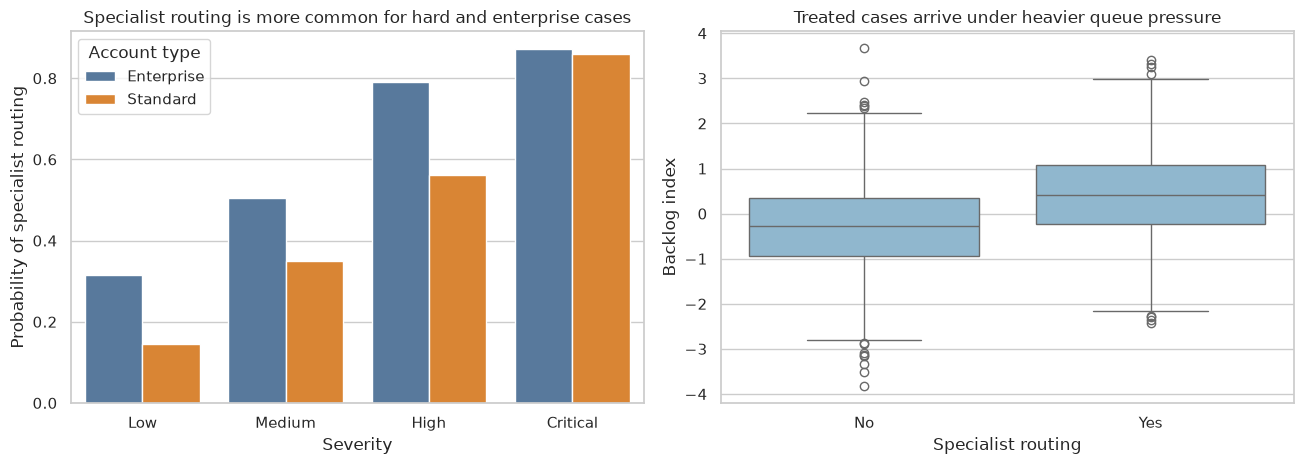

In [2]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
df = make_support_policy_data()

smart_display(df.head())
smart_display(policy_summary_table(df))

assignment_table = (
    df.groupby(['severity', 'account_type'], observed=False)
    .agg(
        policy_rate=('specialist_routing', 'mean'),
        avg_resolution_hours=('resolution_hours', 'mean'),
        avg_backlog=('backlog_index', 'mean'),
        cases=('resolution_hours', 'size'),
    )
    .reset_index()
)
smart_display(assignment_table)

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8))

sns.barplot(
    data=assignment_table,
    x='severity',
    y='policy_rate',
    hue='account_type',
    palette=['#4c78a8', '#f58518'],
    ax=axes[0],
)
axes[0].set_title('Specialist routing is more common for hard and enterprise cases')
axes[0].set_xlabel('Severity')
axes[0].set_ylabel('Probability of specialist routing')
axes[0].legend(title='Account type', frameon=True)

sns.boxplot(
    data=df,
    x='specialist_routing',
    y='backlog_index',
    color='#86b9d8',
    ax=axes[1],
)
axes[1].set_title('Treated cases arrive under heavier queue pressure')
axes[1].set_xlabel('Specialist routing')
axes[1].set_ylabel('Backlog index')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No', 'Yes'])

plt.tight_layout()
plt.show()


The simulated routing dataset is built to make confounding visible. Harder cases are more likely to be routed to senior analysts, and harder cases also take longer. That structure lets the notebook show why a raw difference and an adjusted regression coefficient answer different questions.

### Variable Guide

| Variable | Role in the analysis | Why it matters for inference |
|---|---|---|
| `resolution_hours` | Primary continuous outcome | Leadership wants to know whether the queue policy reduces time to resolution. |
| `specialist_routing` | Policy indicator | This is the treatment-like variable whose effect we want to estimate. |
| `severity` | Core case-mix driver | Harder tickets both take longer and are more likely to receive specialist handling. |
| `backlog_index` | Operational congestion measure | Queue pressure affects both assignment and resolution speed, creating confounding risk. |
| `product_complexity` | Technical complexity proxy | More complex products generate harder tickets and different routing behavior. |
| `prior_incidents` | History / recurrence measure | Repeat incidents often signal deeper operational difficulty. |
| `agent_experience_years` | Workforce capability measure | More experienced analysts usually resolve similar tickets faster. |
| `enterprise_account` | Priority-customer flag | Enterprise cases often receive more intervention but also bring higher stakes and complexity. |
| `channel` and `region` | Context variables | Intake channel and regional workflow differences create systematic variation in outcomes. |
| `true_effect_hours` | Hidden simulation truth | Observed only because this is a synthetic notebook; used to benchmark our inferential procedure. |

The summary table at the top already tells us why naive inference will struggle. Treated cases have longer average resolution time even though the true average policy effect is negative. That reversal is pure selection bias: the policy is deployed to harder cases.


## 3. Raw Difference Versus Regression-Adjusted Effect

We now compare three models:

1. a **naive** regression with only the routing indicator,
2. a **case-mix adjusted** regression with observed drivers of difficulty, and
3. a **flexible mean model** that also allows nonlinear backlog pressure and effect heterogeneity by severity.

The comparison matters. If regression is doing useful inferential work, the estimate on `specialist_routing` should change substantially once the confounding structure is acknowledged.


### How to Read the Main Coefficients

| Term | Practical interpretation |
|---|---|
| `specialist_routing` | Adjusted routing effect for the baseline severity group in the flexible model |
| `backlog_index` | Conditional slope on queue congestion |
| `product_complexity` | Conditional increase associated with harder products |
| `agent_experience_years` | Conditional change per additional year of analyst experience |
| `enterprise_account` | Conditional premium-account difference after adjustment |

This table is intentionally static because it is interpretive scaffolding. The numeric tables and figures around it are the pieces that should move when the data or model changes.


,model,estimate_hours,std_error,ci_lower,ci_upper,true_average_effect_hours
0,Naive raw comparison,1.154884,0.071684,1.014333,1.295435,-0.942622
1,Case-mix adjusted OLS,-0.954566,0.045694,-1.044159,-0.864972,-0.942622
2,Flexible model: low-severity baseline effect,-0.793268,0.079952,-0.950031,-0.636505,-0.761155


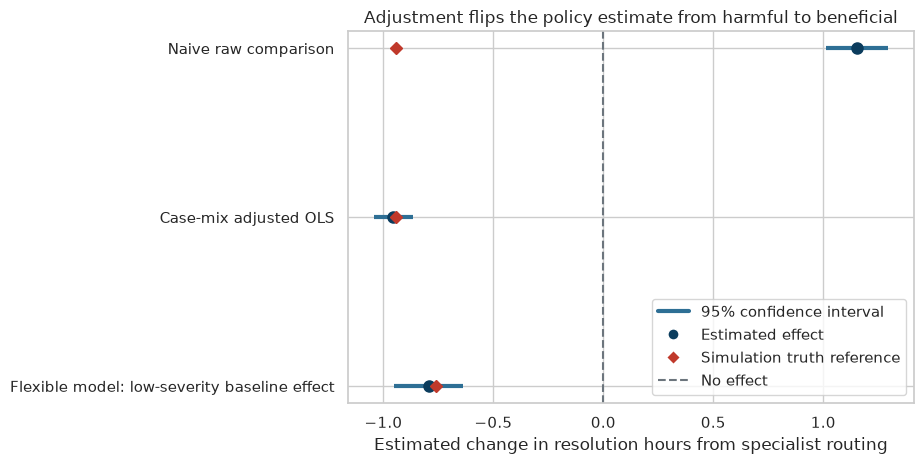

In [3]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
naive_model = smf.ols('resolution_hours ~ specialist_routing', data=df).fit()
adjusted_model = smf.ols(
    'resolution_hours ~ specialist_routing + C(severity) + backlog_index + prior_incidents + '
    'product_complexity + agent_experience_years + enterprise_account + C(channel) + C(region)',
    data=df,
).fit()
flexible_model = smf.ols(
    'resolution_hours ~ specialist_routing * C(severity) + backlog_index + I(backlog_index**2) + '
    'prior_incidents + product_complexity + agent_experience_years + enterprise_account + '
    'C(channel) + C(region)',
    data=df,
).fit()

policy_estimates = pd.DataFrame(
    [
        extract_interval(naive_model, 'specialist_routing', 'Naive raw comparison', df['true_effect_hours'].mean()),
        extract_interval(adjusted_model, 'specialist_routing', 'Case-mix adjusted OLS', df['true_effect_hours'].mean()),
        extract_interval(
            flexible_model,
            'specialist_routing',
            'Flexible model: low-severity baseline effect',
            df.loc[df['severity'].eq('Low'), 'true_effect_hours'].mean(),
        ),
    ]
)
smart_display(policy_estimates)

fig, ax = plt.subplots(figsize=(9.4, 4.8))
y_positions = np.arange(len(policy_estimates))[::-1]

for y, (_, row) in zip(y_positions, policy_estimates.iterrows()):
    ax.hlines(y, row['ci_lower'], row['ci_upper'], color='#2e6f95', linewidth=3)
    ax.plot(row['estimate_hours'], y, 'o', color='#0b3c5d', markersize=8)
    if pd.notna(row['true_average_effect_hours']):
        ax.plot(row['true_average_effect_hours'], y, marker='D', color='#c0392b', markersize=6)

ax.axvline(0, color='#6c757d', linestyle='--', linewidth=1.5, label='No effect')
ax.set_yticks(y_positions)
ax.set_yticklabels(policy_estimates['model'])
ax.set_xlabel('Estimated change in resolution hours from specialist routing')
ax.set_title('Adjustment flips the policy estimate from harmful to beneficial')
ax.legend(
    handles=[
        plt.Line2D([0], [0], color='#2e6f95', linewidth=3, label='95% confidence interval'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#0b3c5d', markersize=8, label='Estimated effect'),
        plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='#c0392b', markersize=7, label='Simulation truth reference'),
        plt.Line2D([0], [0], color='#6c757d', linestyle='--', linewidth=1.5, label='No effect'),
    ],
    frameon=True,
    loc='lower right',
)

plt.tight_layout()
plt.show()


The raw difference is badly misleading. Because difficult cases are preferentially routed to specialists, the naive model attributes the difficulty premium to the policy itself. In the synthetic data, that makes specialist routing look **harmful** even though the true average effect is beneficial.

Once we adjust for severity, backlog, product complexity, customer type, and other observed drivers, the sign flips and the estimate moves close to the true average effect. This is the core inferential lesson: the coefficient on a policy variable is more than a number produced by software. It is the answer to a comparison defined by the rest of the specification.

The flexible model goes one step further. By allowing nonlinear congestion and severity-dependent treatment effects, it stops pretending that the policy works identically for every ticket. That is often the difference between an academic regression table and a model that can actually inform deployment strategy.

## 4. Interaction Terms as Structured Questions

Linear models become much more useful once we stop thinking of them as one-number machines. Interaction terms let us ask structured questions such as:

- Is the policy more useful for critical cases than for routine ones?
- Does the adjusted effect stay constant across operational states?
- Which segments justify paying for the more expensive intervention?

In the flexible model, the low-severity effect is the baseline coefficient on `specialist_routing`. The other interaction terms tell us how much the effect shifts for medium-, high-, and critical-severity cases.

For example,

$$
\tau_{\text{critical}} = \beta_{\text{routing}} + \beta_{\text{routing} \times \text{critical}}.
$$

That is a linear contrast, and the fitted model gives us both an estimate and a confidence interval for it.


,severity,estimated_effect_hours,std_error,ci_lower,ci_upper,true_average_effect_hours
0,Low,-0.793,0.080,-0.950,-0.637,-0.761
1,Medium,-0.989,0.067,-1.119,-0.858,-0.811
2,High,-1.040,0.088,-1.212,-0.868,-1.229
3,Critical,-1.206,0.162,-1.524,-0.888,-1.310


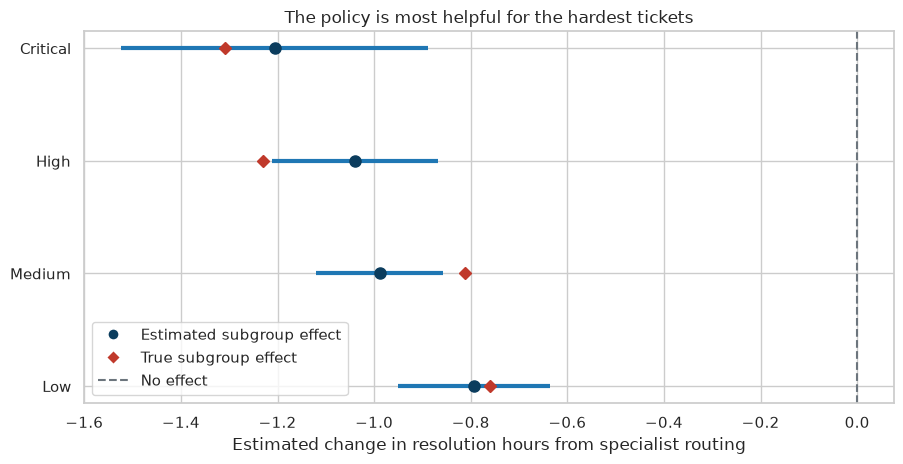

In [4]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
severity_effects = subgroup_effect_table(flexible_model, df)
smart_display(severity_effects)

fig, ax = plt.subplots(figsize=(9.2, 4.8))
x = np.arange(len(severity_effects))

ax.hlines(y=x, xmin=severity_effects['ci_lower'], xmax=severity_effects['ci_upper'], color='#1f77b4', linewidth=3)
ax.plot(severity_effects['estimated_effect_hours'], x, 'o', color='#0b3c5d', markersize=8, label='Estimated subgroup effect')
ax.plot(severity_effects['true_average_effect_hours'], x, 'D', color='#c0392b', markersize=6, label='True subgroup effect')
ax.axvline(0, color='#6c757d', linestyle='--', linewidth=1.5)
ax.set_yticks(x)
ax.set_yticklabels(severity_effects['severity'])
ax.set_xlabel('Estimated change in resolution hours from specialist routing')
ax.set_title('The policy is most helpful for the hardest tickets')
ax.legend(
    handles=[
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#0b3c5d', markersize=8, label='Estimated subgroup effect'),
        plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='#c0392b', markersize=7, label='True subgroup effect'),
        plt.Line2D([0], [0], color='#6c757d', linestyle='--', linewidth=1.5, label='No effect'),
    ],
    frameon=True,
    loc='lower left',
)

plt.tight_layout()
plt.show()


The subgroup pattern is the business answer leadership usually wants. A single overall average may be adequate for a memo, but deployment decisions are often segment-specific.

Here the model shows a clear gradient: specialist routing helps low-severity cases somewhat, but it helps high- and critical-severity cases more. That is exactly the kind of conclusion that a raw mean comparison cannot provide. Without the interaction structure, the organization would either overgeneralize from one average effect or misread the whole policy because the treated cases are systematically harder.

This is also a reminder that coefficient interpretation is relational. The baseline routing coefficient is *not* the effect for everybody. It is the effect for the baseline severity group, with the interaction terms modifying that effect for the other groups.

## 5. Heteroskedasticity Changes the Uncertainty Story

In operational data, difficult cases usually have higher means and higher variance. That matters because ordinary least squares computes classical standard errors under a constant-variance assumption.

If the mean model is still sensible but the variance is not constant, the point estimates do not automatically collapse. The uncertainty calculations become the main concern. White (1980) introduced heteroskedasticity-consistent covariance estimators for exactly this situation, and MacKinnon and White (1985) studied finite-sample improvements such as HC3. A formal Breusch-Pagan diagnostic (Breusch & Pagan, 1979) can help detect variance patterns, but the more important habit is conceptual: **robust standard errors repair the covariance estimate, not the substantive meaning of a bad model**.


,breusch_pagan_lm,breusch_pagan_p_value,breusch_pagan_f_stat,breusch_pagan_f_p_value
0,270.996,0.000,15.485,0.000


,term_label,classical_se,hc3_se,classical_p_value,hc3_p_value
0,Routing effect,0.080,0.069,0.000,0.000
1,Routing x Critical,0.179,0.218,0.022,0.059
2,Backlog index,0.019,0.021,0.000,0.000
3,Enterprise account,0.039,0.039,0.000,0.000


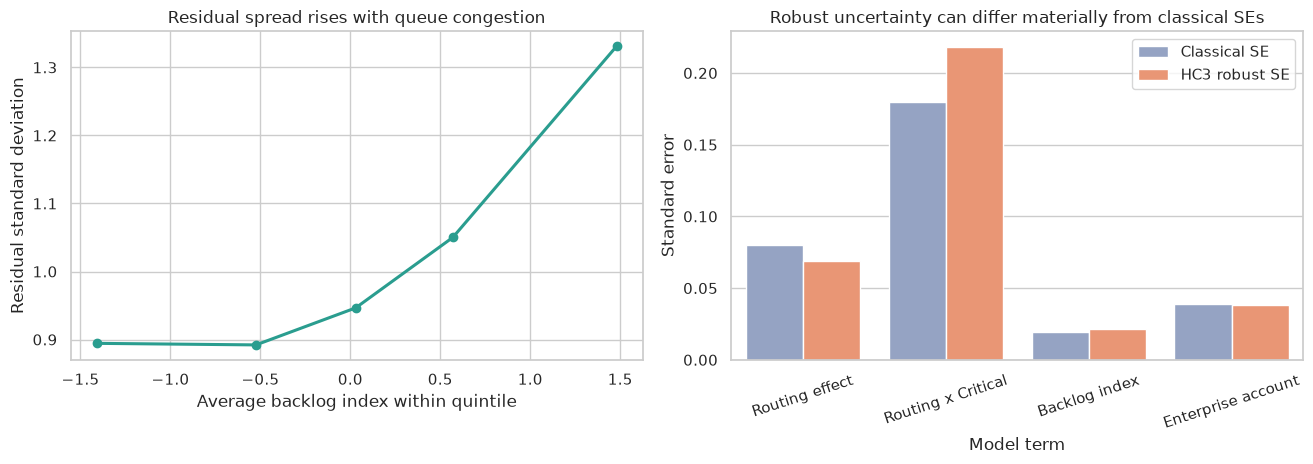

In [5]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
bp_lm, bp_p_value, bp_f, bp_f_p_value = het_breuschpagan(flexible_model.resid, flexible_model.model.exog)

heteroskedasticity_summary = pd.DataFrame(
    [
        {
            'breusch_pagan_lm': bp_lm,
            'breusch_pagan_p_value': bp_p_value,
            'breusch_pagan_f_stat': bp_f,
            'breusch_pagan_f_p_value': bp_f_p_value,
        }
    ]
)
smart_display(heteroskedasticity_summary)

term_labels = {
    'specialist_routing': 'Routing effect',
    'specialist_routing:C(severity)[T.Critical]': 'Routing x Critical',
    'backlog_index': 'Backlog index',
    'enterprise_account': 'Enterprise account',
}
terms_to_compare = list(term_labels)
robust_table = robust_comparison_table(flexible_model, terms_to_compare)
robust_table['term_label'] = robust_table['term'].map(term_labels)
smart_display(robust_table[['term_label', 'classical_se', 'hc3_se', 'classical_p_value', 'hc3_p_value']])

residual_df = pd.DataFrame(
    {
        'fitted': flexible_model.fittedvalues,
        'residual': flexible_model.resid,
        'abs_residual': np.abs(flexible_model.resid),
        'backlog_index': df['backlog_index'],
    }
)
residual_df['backlog_bin'] = pd.qcut(residual_df['backlog_index'], q=5, duplicates='drop')
spread_table = (
    residual_df.groupby('backlog_bin', observed=False)
    .agg(backlog_midpoint=('backlog_index', 'mean'), residual_sd=('residual', 'std'))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.8))

axes[0].plot(spread_table['backlog_midpoint'], spread_table['residual_sd'], marker='o', linewidth=2.2, color='#2a9d8f')
axes[0].set_title('Residual spread rises with queue congestion')
axes[0].set_xlabel('Average backlog index within quintile')
axes[0].set_ylabel('Residual standard deviation')

comparison_long = robust_table.melt(
    id_vars=['term', 'term_label'],
    value_vars=['classical_se', 'hc3_se'],
    var_name='se_type',
    value_name='std_error',
)
comparison_long['se_type'] = comparison_long['se_type'].map({'classical_se': 'Classical SE', 'hc3_se': 'HC3 robust SE'})

sns.barplot(
    data=comparison_long,
    x='term_label',
    y='std_error',
    hue='se_type',
    order=list(term_labels.values()),
    palette=['#8da0cb', '#fc8d62'],
    ax=axes[1],
)
axes[1].set_title('Robust uncertainty can differ materially from classical SEs')
axes[1].set_xlabel('Model term')
axes[1].set_ylabel('Standard error')
axes[1].tick_params(axis='x', rotation=18)
axes[1].legend(title='', frameon=True)

plt.tight_layout()
plt.show()


The Breusch-Pagan result and the residual-spread plot point in the same direction: variance rises in harder operating conditions. That means any inferential summary that relies only on constant-variance standard errors is on shakier ground.

Notice what changes and what does not:

- the coefficient estimates stay the same;
- the robust standard errors change the width of the intervals and sometimes the apparent strength of evidence;
- none of this rescues a bad mean specification.

That distinction is easy to blur in practice. Analysts sometimes talk as if using robust standard errors makes a regression "robust" in every sense. It does not. It makes one part of the inferential machinery more trustworthy under heteroskedasticity.

## 6. Scenario-Level Forecasts and Decision Intervals

Decision makers rarely stop at coefficient tables. They ask scenario questions.

- What happens for a routine ticket if we do not pay for specialist routing?
- What happens for a critical enterprise outage during a backlog spike?
- Are we moving the expected outcome enough to justify the intervention?

Regression lets us answer those questions at two different uncertainty levels:

1. a **confidence interval for the mean** predicted outcome under a specified scenario, and
2. a **prediction interval** for an individual future case.

The first is relevant for policy planning. The second reminds us how noisy any one case remains even after modeling.


,scenario,specialist_routing,severity,backlog_index,enterprise_account,mean,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper,routing_label,account_type
0,Critical enterprise outage,0,Critical,1.550,1,14.674,14.334,15.015,12.607,16.742,Without specialist routing,Enterprise
1,Critical enterprise outage,1,Critical,1.550,1,13.469,13.275,13.662,11.420,15.517,With specialist routing,Enterprise
2,Routine standard ticket,0,Low,-0.350,0,4.983,4.874,5.093,2.941,7.025,Without specialist routing,Standard
3,Routine standard ticket,1,Low,-0.350,0,4.190,4.021,4.359,2.144,6.236,With specialist routing,Standard


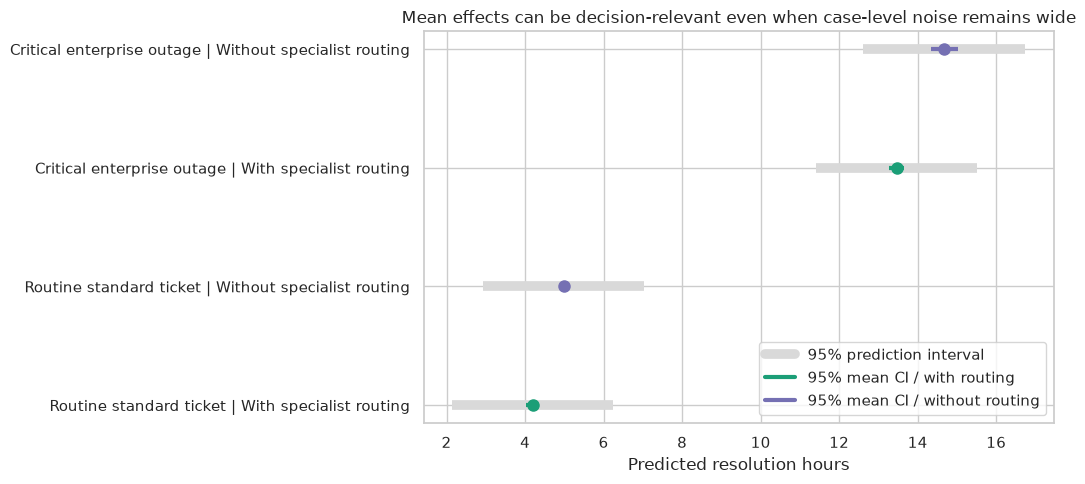

In [6]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
scenario_rows = pd.DataFrame(
    [
        {
            'scenario': 'Routine standard ticket',
            'severity': 'Low',
            'backlog_index': -0.35,
            'prior_incidents': 1,
            'product_complexity': 0.32,
            'agent_experience_years': 5.6,
            'enterprise_account': 0,
            'channel': 'Email',
            'region': 'North America',
        },
        {
            'scenario': 'Critical enterprise outage',
            'severity': 'Critical',
            'backlog_index': 1.55,
            'prior_incidents': 6,
            'product_complexity': 0.90,
            'agent_experience_years': 3.2,
            'enterprise_account': 1,
            'channel': 'Escalation',
            'region': 'Latin America',
        },
    ]
)

scenario_rows['severity'] = pd.Categorical(scenario_rows['severity'], categories=SEVERITY_ORDER, ordered=True)
scenario_rows['channel'] = pd.Categorical(scenario_rows['channel'], categories=CHANNEL_ORDER, ordered=True)
scenario_rows['region'] = pd.Categorical(scenario_rows['region'], categories=REGION_ORDER, ordered=True)

scenario_pairs = pd.concat(
    [
        scenario_rows.assign(specialist_routing=0),
        scenario_rows.assign(specialist_routing=1),
    ],
    ignore_index=True,
).sort_values(['scenario', 'specialist_routing']).reset_index(drop=True)

scenario_predictions = paired_scenario_predictions(flexible_model, scenario_pairs)
smart_display(scenario_predictions)

fig, ax = plt.subplots(figsize=(10.8, 5.0))
plot_df = scenario_predictions.copy()
plot_df['label'] = plot_df['scenario'] + ' | ' + plot_df['routing_label']
y_positions = np.arange(len(plot_df))[::-1]
colors = np.where(plot_df['specialist_routing'].eq(1), '#1b9e77', '#7570b3')

for y, (_, row), color in zip(y_positions, plot_df.iterrows(), colors):
    ax.hlines(y, row['obs_ci_lower'], row['obs_ci_upper'], color='#d9d9d9', linewidth=7)
    ax.hlines(y, row['mean_ci_lower'], row['mean_ci_upper'], color=color, linewidth=3)
    ax.plot(row['mean'], y, 'o', color=color, markersize=8)

ax.set_yticks(y_positions)
ax.set_yticklabels(plot_df['label'])
ax.set_xlabel('Predicted resolution hours')
ax.set_title('Mean effects can be decision-relevant even when case-level noise remains wide')
ax.legend(
    handles=[
        plt.Line2D([0], [0], color='#d9d9d9', linewidth=7, label='95% prediction interval'),
        plt.Line2D([0], [0], color='#1b9e77', linewidth=3, label='95% mean CI / with routing'),
        plt.Line2D([0], [0], color='#7570b3', linewidth=3, label='95% mean CI / without routing'),
    ],
    frameon=True,
    loc='lower right',
)

plt.tight_layout()
plt.show()


The scenario table and interval plot move the regression from coefficient interpretation to decision support. Specialist routing lowers the predicted mean resolution time in both scenarios, but the individual-case prediction intervals remain much wider than the mean intervals.

That distinction is the lesson. Regression can support a policy decision about expected performance across many similar cases, but it cannot promise the exact outcome for the next ticket. A good recommendation should report both the mean effect and the residual case-level uncertainty.


In [7]:
# Simulate data or resample observations to study variability and uncertainty.
naive_effect = float(naive_model.params['specialist_routing'])
adjusted_effect = float(adjusted_model.params['specialist_routing'])
critical_effect = float(severity_effects.loc[severity_effects['severity'].eq('Critical'), 'estimated_effect_hours'].iloc[0])
critical_truth = float(severity_effects.loc[severity_effects['severity'].eq('Critical'), 'true_average_effect_hours'].iloc[0])
robust_shift = float(
    robust_table.loc[robust_table['term'].eq('specialist_routing'), 'hc3_se'].iloc[0]
    - robust_table.loc[robust_table['term'].eq('specialist_routing'), 'classical_se'].iloc[0]
)
robust_direction = 'larger' if robust_shift > 0 else 'smaller'

memo = f"""
## 7. Decision Memo

**Question.** Should the support organization continue funding specialist routing, and if so for whom?

**Adjusted answer.** The raw comparison suggests specialist routing increases resolution time by **{naive_effect:0.2f} hours**, but that conclusion is selection-biased because harder tickets are more likely to be routed. After regression adjustment, the average effect is about **{adjusted_effect:0.2f} hours**, meaning the policy reduces expected resolution time.

**Where it helps most.** In the flexible interaction model, the estimated effect for **critical cases** is about **{critical_effect:0.2f} hours**, close to the simulated truth of **{critical_truth:0.2f} hours**. That makes specialist routing most defensible for the hardest tickets, where both operational stakes and estimated benefit are largest.

**Uncertainty posture.** The heteroskedasticity diagnostics are strong, and the HC3 robust standard error on the routing coefficient is about **{abs(robust_shift):0.3f} hours {robust_direction}** than the classical one in this run. So any launch memo should report robust intervals alongside default OLS output.

**Recommendation.** Keep specialist routing, prioritize it for high- and critical-severity cases, and avoid evaluating it with raw treated-versus-control averages. The model is useful because it creates an adjusted comparison and an uncertainty statement, not because it turns observational data into certainty.
"""

display(Markdown(memo))



## 7. Decision Memo

**Question.** Should the support organization continue funding specialist routing, and if so for whom?

**Adjusted answer.** The raw comparison suggests specialist routing increases resolution time by **1.15 hours**, but that conclusion is selection-biased because harder tickets are more likely to be routed. After regression adjustment, the average effect is about **-0.95 hours**, meaning the policy reduces expected resolution time.

**Where it helps most.** In the flexible interaction model, the estimated effect for **critical cases** is about **-1.21 hours**, close to the simulated truth of **-1.31 hours**. That makes specialist routing most defensible for the hardest tickets, where both operational stakes and estimated benefit are largest.

**Uncertainty posture.** The heteroskedasticity diagnostics are strong, and the HC3 robust standard error on the routing coefficient is about **0.011 hours smaller** than the classical one in this run. So any launch memo should report robust intervals alongside default OLS output.

**Recommendation.** Keep specialist routing, prioritize it for high- and critical-severity cases, and avoid evaluating it with raw treated-versus-control averages. The model is useful because it creates an adjusted comparison and an uncertainty statement, not because it turns observational data into certainty.


The memo is the final interpretation check for the regression workflow. It explains why the naive comparison is misleading, where the adjusted model suggests routing helps most, and why robust intervals should be reported when heteroskedasticity is present.

For decision science, this is the right posture: use the model to create a better comparison and an uncertainty statement, while still acknowledging that observational regression does not automatically become causal proof.


<!-- real-data-companion-course01 -->
## Real-Data Companion: Grunfeld Investment as Adjusted Linear Inference

The synthetic routing example above treats linear regression as an adjusted comparison engine. The Grunfeld investment panel gives a real economic dataset where adjustment matters for a different reason: firms differ systematically in scale, capital stock, market value, and investment behavior across time.

The unit is a firm-year observation. The outcome is investment, and common predictors include firm market value and capital stock. Because the same firms appear repeatedly, a pooled regression can blend within-firm and between-firm comparisons unless the formula accounts for firm-level differences.

The companion compares a pooled linear model with a firm-adjusted model. The experiment is not a causal claim about market value causing investment. It is a specification lesson: regression coefficients are conditional on the comparison structure built into the model, and real panel data make that structure impossible to ignore.

Data source: [Grunfeld investment data in statsmodels](https://www.statsmodels.org/stable/datasets/generated/grunfeld.html).

,model,value_coef,capital_coef,r_squared
0,Pooled OLS,0.115,0.228,0.818
1,Firm-adjusted OLS,0.110,0.310,0.946


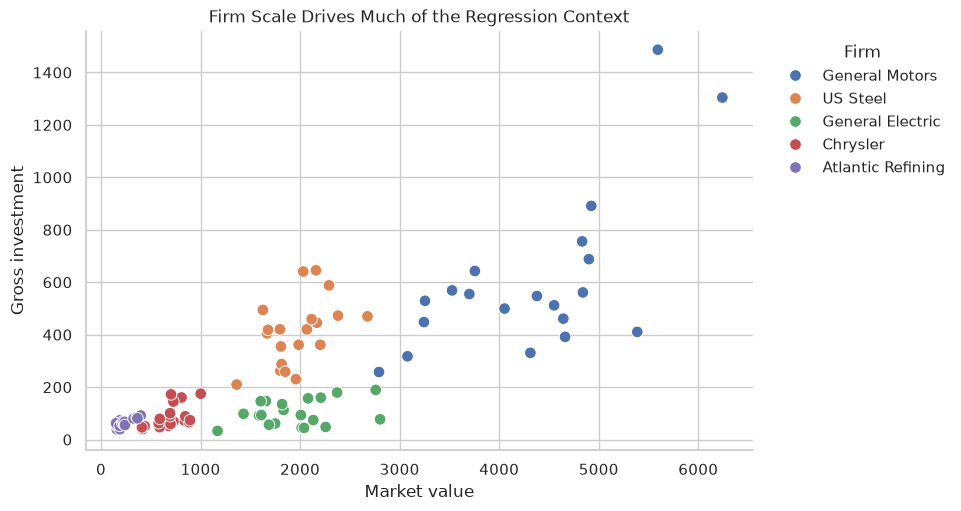

In [8]:
# real-data-companion-course01
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display
from notebooks._shared.real_data import load_statsmodels_grunfeld, optional_data_note

RUN_REAL_DATA_COMPANION = True

if RUN_REAL_DATA_COMPANION:
    grunfeld = load_statsmodels_grunfeld().copy()
    pooled = smf.ols("invest ~ value + capital", data=grunfeld).fit()
    firm_adjusted = smf.ols("invest ~ value + capital + C(firm)", data=grunfeld).fit(cov_type="HC3")

    comparison = pd.DataFrame(
        [
            {"model": "Pooled OLS", "value_coef": pooled.params["value"], "capital_coef": pooled.params["capital"], "r_squared": pooled.rsquared},
            {"model": "Firm-adjusted OLS", "value_coef": firm_adjusted.params["value"], "capital_coef": firm_adjusted.params["capital"], "r_squared": firm_adjusted.rsquared},
        ]
    )
    smart_display(comparison.round(4))

    grunfeld_plot = grunfeld.assign(
        pooled_fitted=pooled.fittedvalues,
        firm_adjusted_fitted=firm_adjusted.fittedvalues,
    )
    top_firms = grunfeld_plot.groupby("firm")["invest"].mean().nlargest(5).index

    fig, ax = plt.subplots(figsize=(9.5, 5), constrained_layout=True)
    sns.scatterplot(data=grunfeld_plot.query("firm in @top_firms"), x="value", y="invest", hue="firm", ax=ax, s=70)
    ax.set_title("Firm Scale Drives Much of the Regression Context")
    ax.set_xlabel("Market value")
    ax.set_ylabel("Gross investment")
    ax.legend(title="Firm", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    sns.despine(fig=fig)
    plt.show()
else:
    optional_data_note(
        "Grunfeld Investment Data",
        "https://www.statsmodels.org/stable/datasets/generated/grunfeld.html",
        "RUN_REAL_DATA_COMPANION",
    )

<!-- real-data-companion-course01 -->
The companion reinforces the main regression warning. A coefficient is not just a property of a variable. It is a property of a variable inside a comparison design.

In the pooled model, variation across very different firms and variation within the same firm over time are blended together. Adding firm indicators changes the comparison: the coefficients are now estimated after accounting for stable firm-level scale differences. This is why the capital coefficient changes meaningfully and the model fit rises. The lesson is that regression formulas define the comparison being reported; fixed effects are useful when stable firm-level scale differences are part of the question.

## What to Remember

1. A regression coefficient is an answer to a **specified comparison**, not an automatically causal fact.
2. Raw and adjusted estimates can point in opposite directions when policy assignment is confounded.
3. Interaction terms turn one average effect into a structured set of subgroup-specific questions.
4. Heteroskedasticity matters mainly because it distorts classical uncertainty calculations.
5. Robust standard errors improve covariance estimation under nonconstant variance, but they do not fix mean-model misspecification.
6. Prediction intervals for individual cases remain much wider than confidence intervals for mean effects, which is exactly why operational decisions need both average-effect thinking and noise awareness.


## References

- Breusch, T. S., & Pagan, A. R. (1979). *A simple test for heteroscedasticity and random coefficient variation.* *Econometrica, 47*(5), 1287-1294. [https://doi.org/10.2307/1911963](https://doi.org/10.2307/1911963)
- MacKinnon, J. G., & White, H. (1985). *Some heteroskedasticity-consistent covariance matrix estimators with improved finite sample properties.* *Journal of Econometrics, 29*(3), 305-325. [https://doi.org/10.1016/0304-4076(85)90158-7](https://doi.org/10.1016/0304-4076%2885%2990158-7)
- White, H. (1980). *A heteroskedasticity-consistent covariance matrix estimator and a direct test for heteroskedasticity.* *Econometrica, 48*(4), 817-838. [https://doi.org/10.2307/1912934](https://doi.org/10.2307/1912934)
- White, H. (1982). *Maximum likelihood estimation of misspecified models.* *Econometrica, 50*(1), 1-25. [https://doi.org/10.2307/1912526](https://doi.org/10.2307/1912526)
